# Признаки МО из OpenStreetMap

**Задача.** Для заданных муниципальных образований (МО) собрать из OSM простые признаки, которые описывают, *что находится на территории*: какие заведения и службы, сколько промышленных и жилых зон, дороги и железные дороги. Эти признаки дополнят траты из эксперимента 1 (`mo_clustering.ipynb`), где МО различались в основном размером города.

**Что получается на выходе.** Таблица `results/osm_features.csv`: одна строка на МО, ключ — столбец `mo` с тем же названием, что в данных о тратах.

| Блок признаков | Примеры | Что характеризует |
|---|---|---|
| Заведения и службы (POI) | доля образования, медицины, общепита, торговли, туризма среди всех POI; плотность POI на км² | сервисная экономика, туризм, роль административного центра |
| Землепользование | доля площади МО под промзонами, жильём, сельхозугодьями, лесом | промышленный, аграрный или городской профиль |
| Промышленные объекты | число заводов, электростанций, карьеров | промышленность и добыча |
| Транспорт | км крупных дорог и железных дорог на км², вокзалы, аэродром | связность, транзитная роль |
| Здания (по желанию) | плотность застройки, доля многоквартирных и промышленных зданий | тип застройки |

**Как устроен ноутбук.**
1. Границы МО: из файла (основной вариант) или геокодингом по названию (запасной).
2. Для каждого МО скачиваем объекты OSM внутри границы и сохраняем в кэш на диск. Повторный запуск берёт данные из кэша, поэтому прерванный расчёт можно продолжить.
3. Из объектов считаем признаки.
4. Проверяем полноту данных и сохраняем таблицу.

**Главное ограничение.** OSM заполнен неравномерно: города размечены подробно, сельские районы — слабо. Поэтому *число* объектов отражает ещё и активность картографов. *Доли* (структура POI, доля площади) устойчивее, для кластеризации лучше брать их. В разделе 4 есть проверка: МО с малым числом объектов помечаются как ненадёжные.

In [3]:
# pip install osmnx geopandas pyarrow tqdm
import re
import warnings
from pathlib import Path

import geopandas as gpd
import numpy as np
import osmnx as ox
import pandas as pd
import shapely
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 220)
print('osmnx', ox.__version__, '| geopandas', gpd.__version__, '| shapely', shapely.__version__)

osmnx 2.1.1 | geopandas 1.2.0 | shapely 2.1.2


/opt/conda/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Конфигурация

* **Границы из файла.** Укажите `BOUNDARIES_PATH` (GeoJSON, GeoPackage, Shapefile) и `NAME_COL` — столбец с названием МО. Названия должны совпадать с названиями в данных о тратах.
* **Геокодинг.** Если файла нет, оставьте `BOUNDARIES_PATH = None` и заполните `GEOCODE_QUERIES`: название МО → поисковый запрос. Геокодер иногда возвращает границу города вместо городского округа или не тот объект, поэтому границы нужно проверить глазами (раздел 1).
* **Здания** выключены по умолчанию: для крупного города это сотни тысяч объектов и долгая загрузка.

In [4]:
costs = pd.read_parquet('data/potrebitelskie-beznalicnye-rashody-na-urovne-munizipalnyh-obrazovanij_ru_1764079373653.parquet')
GEOCODE_QUERIES = list(costs.mo.unique())

In [5]:
INCLUDE_BUILDINGS = False              # здания: долго для крупных городов
MIN_POI_RELIABLE = 30                  # меньше POI — доли считаем ненадёжными

CACHE_DIR = Path('osm_cache')          # сырые объекты OSM по каждому МО
OUT_DIR = Path('results')
CACHE_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)

ox.settings.use_cache = True           # osmnx дополнительно кэширует ответы сервера
ox.settings.requests_timeout = 300

## 1. Границы МО

In [6]:
costs = pd.read_parquet('data/potrebitelskie-beznalicnye-rashody-na-urovne-munizipalnyh-obrazovanij_ru_1764079373653.parquet')
oktmo_geo = gpd.read_file('data/Municipalities_Russia_2025.geojson')

costs['short_name'] = costs['mo'].apply(lambda x: ' '.join([token for token in x.split() if token[0].isupper()]))
oktmo_geo['short_name'] = oktmo_geo['name'].apply(
    lambda x: ' '.join([token for token in x.split() if token[0].isupper() and token != 'Муниципальный'])
)

costs_geo = costs.merge(oktmo_geo[['short_name', 'oktmo', 'geometry']], on='short_name', how="inner")
boundaries = costs_geo[['mo', 'geometry']].drop_duplicates('mo').reset_index(drop=True)
boundaries = gpd.GeoDataFrame(boundaries, geometry='geometry', crs='EPSG:3857')

print(f'МО: {len(boundaries)}')

МО: 2081


,mo,тип геометрии,"площадь, км²"
239,внутригородская территория города федерального...,MultiPolygon,1.067840
862,внутригородская территория города федерального...,MultiPolygon,1.098167
1499,внутригородская территория города федерального...,MultiPolygon,1.727208
516,внутригородская территория города федерального...,MultiPolygon,1.779768
1429,внутригородская территория города федерального...,MultiPolygon,1.934561
...,...,...,...
1193,Булунский муниципальный район,MultiPolygon,219985.370911
349,Анадырский муниципальный район,MultiPolygon,287236.102128
1642,Оленекский эвенкийский национальный муниципаль...,MultiPolygon,318463.322071
1208,Эвенкийский муниципальный район,MultiPolygon,763489.138766


<Axes: xlabel='Easting [metre]', ylabel='Northing [metre]'>

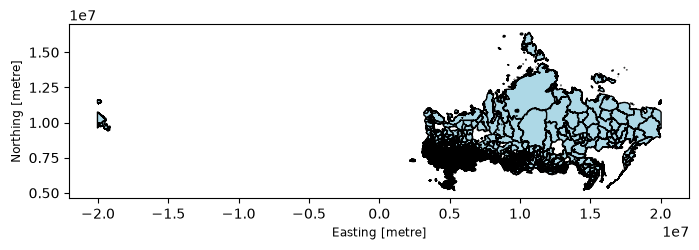

In [7]:
# Проверка границ: площадь и тип геометрии
def area_km2(geometry):
    # Площадь одной геометрии (WGS84) в км², через подходящую зону UTM
    s = gpd.GeoSeries([geometry], crs='EPSG:3857')
    s = s.to_crs(epsg=4326)
    return s.to_crs(s.estimate_utm_crs()).area.iloc[0] / 1e6

check = boundaries[['mo']].copy()
check['тип геометрии'] = boundaries.geom_type.values
check['площадь, км²'] = [area_km2(g) for g in boundaries.geometry]
display(check.sort_values('площадь, км²'))

boundaries.plot(figsize=(8, 5), edgecolor='black', facecolor='lightblue')

## 2. Загрузка объектов OSM

Для каждого МО одним запросом скачиваем все объекты с нужными тегами внутри границы. Запрос идёт к общедоступному серверу Overpass.

**О времени работы.** Город скачивается за секунды или минуты. Большой сельский район osmnx сам делит на части и качает дольше. Для нескольких десятков или сотен МО такой способ подходит. Для всех 1952 МО быстрее один раз скачать выгрузку России с Geofabrik (`russia-latest.osm.pbf`) и читать её локально, например через `pyrosm` или `quackosm`. В этом случае меняется только функция `fetch_osm`: всё остальное работает с её результатом — таблицей объектов со столбцами-тегами.

In [8]:
TAGS = {
    'amenity': True, 'shop': True, 'tourism': True, 'leisure': True, 'office': True, 'craft': True,
    'landuse': True,
    'natural': ['wood', 'water'],
    'man_made': ['works', 'wastewater_plant', 'petroleum_well', 'mineshaft', 'pier'],
    'power': ['plant'],
    'railway': ['rail', 'station', 'halt'],
    'highway': ['motorway', 'trunk', 'primary', 'secondary', 'tertiary'],
    'aeroway': ['aerodrome'],
}
if INCLUDE_BUILDINGS:
    TAGS['building'] = True


def cache_path(mo):
    return CACHE_DIR / (re.sub(r'[^\w\-]+', '_', mo) + '.parquet')


def fetch_osm(mo, polygon):
    # Объекты OSM внутри границы МО: geometry + по столбцу на каждый тег из TAGS
    path = cache_path(mo)
    if path.exists():
        return gpd.read_parquet(path)
    try:
        osm = ox.features_from_polygon(polygon, TAGS)
    except Exception as e:
        if 'InsufficientResponse' not in type(e).__name__:    # «ничего не найдено» — нормальный случай
            raise
        osm = gpd.GeoDataFrame({'geometry': []}, geometry='geometry', crs=4326)
    columns = ['geometry'] + [t for t in TAGS if t in osm.columns]
    osm = osm[columns].reset_index(drop=True)
    osm.to_parquet(path)
    return osm

In [9]:
boundaries = boundaries.to_crs('EPSG:4326')

failed = []
for mo, polygon in tqdm(list(zip(boundaries['mo'], boundaries.geometry)), desc='Загрузка OSM'):
    try:
        fetch_osm(mo, polygon)
    except Exception as e:
        failed.append((mo, repr(e)[:200]))

print(f'Загружено: {len(boundaries) - len(failed)} из {len(boundaries)}')
if failed:
    print('Ошибки (перезапустите ячейку, чтобы повторить только для них):')
    display(pd.DataFrame(failed, columns=['mo', 'ошибка']))

Загрузка OSM: 100%|██████████| 2081/2081 [32:01:38<00:00, 55.41s/it]   

Загружено: 7 из 2081
Ошибки (перезапустите ячейку, чтобы повторить только для них):


,mo,ошибка
0,Кичменгско-Городецкий муниципальный округ,"ConnectionError(MaxRetryError(""HTTPSConnection..."
1,Михайловский муниципальный район,"ConnectionError(MaxRetryError(""HTTPSConnection..."
2,городской округ Ивдельский,"ConnectionError(MaxRetryError(""HTTPSConnection..."
3,муниципальный округ Опочецкий,ValueError('The geometry of `polygon` is inval...
4,внутригородская территория города федерального...,"ConnectionError(MaxRetryError(""HTTPSConnection..."
...,...,...
2069,Холмский муниципальный район,"ConnectionError(MaxRetryError(""HTTPSConnection..."
2070,внутригородская территория города федерального...,"ConnectionError(MaxRetryError(""HTTPSConnection..."
2071,внутригородская территория города федерального...,"ConnectionError(MaxRetryError(""HTTPSConnection..."
2072,Атнинский муниципальный район,"ConnectionError(MaxRetryError(""HTTPSConnection..."


## 3. Расчёт признаков

### Группы заведений (POI)
POI — любой объект с тегом `amenity`, `shop`, `tourism`, `leisure`, `office` или `craft`. Тысячи значений тегов сводим к полутора десяткам понятных групп. Словарь ниже можно свободно менять.

* Уличная мебель и мелкая инфраструктура (скамейки, урны, парковки) исключены: они показывают подробность разметки, а не экономику.
* Если у объекта несколько тегов, группа берётся по первому подходящему в порядке `POI_RULES`.

In [ ]:
IGNORE_AMENITY = {'bench', 'waste_basket', 'waste_disposal', 'recycling', 'parking', 'parking_space',
                  'parking_entrance', 'bicycle_parking', 'motorcycle_parking', 'toilets', 'shelter',
                  'drinking_water', 'water_point', 'post_box', 'telephone', 'vending_machine', 'fountain',
                  'grit_bin', 'loading_dock', 'clock', 'hunting_stand', 'bbq', 'give_box'}

AMENITY_GROUPS = {
    **dict.fromkeys(['school', 'kindergarten', 'college', 'university', 'music_school', 'language_school',
                     'driving_school', 'childcare', 'training', 'research_institute'], 'образование'),
    **dict.fromkeys(['hospital', 'clinic', 'doctors', 'dentist', 'pharmacy', 'veterinary',
                     'nursing_home', 'social_facility'], 'здоровье и соцслужбы'),
    **dict.fromkeys(['restaurant', 'cafe', 'fast_food', 'bar', 'pub', 'food_court', 'biergarten',
                     'ice_cream', 'canteen'], 'общепит'),
    **dict.fromkeys(['bank', 'atm', 'bureau_de_change', 'payment_terminal'], 'финансы'),
    **dict.fromkeys(['townhall', 'courthouse', 'police', 'fire_station', 'post_office', 'prison',
                     'public_building', 'register_office', 'customs', 'ranger_station'], 'госуслуги'),
    **dict.fromkeys(['theatre', 'cinema', 'library', 'arts_centre', 'community_centre', 'nightclub',
                     'events_venue', 'exhibition_centre', 'planetarium'], 'культура'),
    **dict.fromkeys(['place_of_worship', 'monastery'], 'религия'),
    **dict.fromkeys(['fuel', 'car_wash', 'car_rental', 'charging_station', 'bus_station', 'taxi',
                     'ferry_terminal', 'vehicle_inspection'], 'транспорт и авто'),
    'marketplace': 'торговля: продукты',
}
SHOP_GROUPS = {
    **dict.fromkeys(['supermarket', 'convenience', 'greengrocer', 'butcher', 'bakery', 'alcohol',
                     'beverages', 'seafood', 'dairy', 'farm', 'confectionery', 'deli'], 'торговля: продукты'),
    **dict.fromkeys(['car', 'car_repair', 'car_parts', 'tyres', 'motorcycle'], 'транспорт и авто'),
}
TOURISM_GROUPS = {
    **dict.fromkeys(['hotel', 'hostel', 'guest_house', 'motel', 'apartment', 'chalet', 'camp_site',
                     'resort', 'alpine_hut'], 'туризм: размещение'),
}

# (тег, словарь «значение → группа», группа для остальных значений)
POI_RULES = [
    ('amenity', AMENITY_GROUPS, 'прочие услуги'),
    ('shop', SHOP_GROUPS, 'торговля: прочее'),
    ('tourism', TOURISM_GROUPS, 'туризм: достопримечательности'),
    ('office', {}, 'офисы'),
    ('craft', {}, 'ремёсла и мастерские'),
    ('leisure', {}, 'досуг и спорт'),
]


def poi_groups(osm):
    # Для каждого объекта — группа POI или NaN, если объект не является POI
    group = pd.Series(np.nan, index=osm.index, dtype=object)
    for tag, mapping, default in POI_RULES:
        if tag not in osm.columns:
            continue
        todo = osm[tag].notna() & group.isna()
        if tag == 'amenity':
            todo &= ~osm[tag].isin(IGNORE_AMENITY)
        group[todo] = osm.loc[todo, tag].map(mapping).fillna(default)
    return group

### Землепользование, промышленность, транспорт

* **Доля площади.** Полигоны одной группы объединяем (чтобы перекрытия не считались дважды), обрезаем по границе МО и делим площадь на площадь МО. Разные группы могут перекрываться между собой, поэтому сумма долей не обязана равняться 1.
* **Длина дорог и железных дорог** считается по части линий внутри границы и делится на площадь МО.
* Площади и длины считаем в метрической проекции (зона UTM подбирается по МО).

In [ ]:
LANDUSE_GROUPS = {
    'промзоны': ('landuse', ['industrial', 'quarry', 'landfill', 'port', 'depot', 'railway']),
    'жильё': ('landuse', ['residential']),
    'коммерция': ('landuse', ['commercial', 'retail']),
    'сельхозугодья': ('landuse', ['farmland', 'farmyard', 'meadow', 'orchard', 'vineyard',
                                  'greenhouse_horticulture', 'animal_keeping']),
    'дачи и сады': ('landuse', ['allotments']),
    'лес': ('landuse', ['forest']),
    'лес (natural)': ('natural', ['wood']),
    'вода': ('natural', ['water']),
    'военные': ('landuse', ['military']),
}
BUILDING_GROUPS = {
    'многоквартирные': ['apartments', 'dormitory'],
    'частные дома': ['house', 'detached', 'semidetached_house', 'bungalow', 'cabin', 'terrace', 'residential'],
    'промышленные и склады': ['industrial', 'warehouse', 'manufacture', 'hangar'],
    'коммерческие': ['commercial', 'retail', 'office', 'supermarket', 'kiosk', 'hotel'],
    'сельхоз': ['farm', 'farm_auxiliary', 'barn', 'cowshed', 'greenhouse', 'stable', 'sty'],
    'гаражи': ['garage', 'garages'],
}


def select(osm, tag, values=None):
    # Объекты с тегом tag (и значением из списка values, если он задан)
    if tag not in osm.columns:
        return osm.iloc[0:0]
    mask = osm[tag].notna() if values is None else osm[tag].isin(values)
    return osm[mask]


def polygon_area_km2(objects, border):
    # Площадь объединения полигонов внутри границы МО, км²
    polys = objects[objects.geom_type.isin(['Polygon', 'MultiPolygon'])]
    if polys.empty:
        return 0.0
    union = shapely.union_all(np.asarray(polys.geometry.make_valid()))
    return union.intersection(border).area / 1e6


def line_length_km(objects, border):
    # Длина линий внутри границы МО, км
    lines = objects[objects.geom_type.isin(['LineString', 'MultiLineString'])]
    if lines.empty:
        return 0.0
    return lines.geometry.intersection(border).length.sum() / 1e3


def compute_features(osm, polygon):
    # Все признаки одного МО по объектам OSM и границе (WGS84)
    utm = gpd.GeoSeries([polygon], crs=4326).estimate_utm_crs()
    border = gpd.GeoSeries([polygon], crs=4326).to_crs(utm).iloc[0]
    osm = osm.to_crs(utm)
    area = border.area / 1e6
    f = {'площадь, км²': area, 'объектов OSM': len(osm)}

    # --- POI: число, плотность, структура
    groups = poi_groups(osm).dropna()
    f['POI всего'] = len(groups)
    f['POI на км²'] = len(groups) / area
    for g, n in groups.value_counts().items():
        f[f'POI число: {g}'] = n
        f[f'POI доля: {g}'] = n / len(groups)

    # --- землепользование: доля площади МО
    for name, (tag, values) in LANDUSE_GROUPS.items():
        f[f'Площадь доля: {name}'] = polygon_area_km2(select(osm, tag, values), border) / area

    # --- промышленные объекты
    f['Число: промзоны'] = len(select(osm, 'landuse', ['industrial']))
    f['Число: заводы (man_made=works)'] = len(select(osm, 'man_made', ['works']))
    f['Число: карьеры и шахты'] = len(select(osm, 'landuse', ['quarry'])) + len(select(osm, 'man_made', ['mineshaft']))
    f['Число: нефтяные скважины'] = len(select(osm, 'man_made', ['petroleum_well']))
    f['Число: электростанции'] = len(select(osm, 'power', ['plant']))

    # --- транспорт
    f['Дороги крупные, км на км²'] = line_length_km(select(osm, 'highway'), border) / area
    f['Ж/д, км на км²'] = line_length_km(select(osm, 'railway', ['rail']), border) / area
    f['Число: ж/д станции'] = len(select(osm, 'railway', ['station', 'halt']))
    f['Есть аэродром'] = int(len(select(osm, 'aeroway', ['aerodrome'])) > 0)
    f['Есть причалы'] = int(len(select(osm, 'man_made', ['pier'])) > 0)

    # --- здания (если включены)
    if INCLUDE_BUILDINGS:
        buildings = select(osm, 'building')
        f['Зданий на км²'] = len(buildings) / area
        f['Застроено, доля площади'] = polygon_area_km2(buildings, border) / area
        for name, values in BUILDING_GROUPS.items():
            f[f'Здания доля: {name}'] = len(select(osm, 'building', values)) / max(len(buildings), 1)
        f['Здания доля: тип не указан'] = len(select(osm, 'building', ['yes'])) / max(len(buildings), 1)
    return f

In [ ]:
rows = {}
for mo, polygon in tqdm(list(zip(boundaries['mo'], boundaries.geometry)), desc='Признаки'):
    if cache_path(mo).exists():                       # МО с ошибкой загрузки пропускаем
        rows[mo] = compute_features(fetch_osm(mo, polygon), polygon)

features = pd.DataFrame.from_dict(rows, orient='index').rename_axis('mo')
# Группа POI, которой в МО нет, — это 0 объектов, а не пропуск
poi_cols = [c for c in features.columns if c.startswith('POI ')]
features[poi_cols] = features[poi_cols].fillna(0)

print(f'МО: {len(features)}, признаков: {features.shape[1]}')
display(features.T)

## 4. Проверка полноты и сохранение

Признаки-доли имеют смысл, только если в МО размечено достаточно объектов. МО, где POI меньше `MIN_POI_RELIABLE`, получают отметку `надёжно = False`: их доли POI лучше не использовать или заменить пропуском.

Плотность POI сама по себе говорит и об экономике, и о полноте разметки. Разделить эти два эффекта можно будет после добавления населения: POI на 1000 жителей.

In [ ]:
features['надёжно'] = features['POI всего'] >= MIN_POI_RELIABLE
print(f"Надёжных МО: {features['надёжно'].sum()} из {len(features)}")
display(features[['площадь, км²', 'объектов OSM', 'POI всего', 'POI на км²', 'надёжно']].sort_values('POI всего'))

features.to_csv(OUT_DIR / 'osm_features.csv')
print('Сохранено:', OUT_DIR / 'osm_features.csv')

### Быстрый взгляд на результат
Две сводки для проверки здравым смыслом: структура POI по МО и «промышленный» рейтинг. Если известный промышленный город оказался внизу рейтинга, стоит посмотреть его границу и разметку в OSM.

In [ ]:
share_cols = [c for c in features.columns if c.startswith('POI доля: ')]
print('Структура POI, % (строки — МО):')
display((features.loc[features['надёжно'], share_cols] * 100).round(1)
        .rename(columns=lambda c: c.replace('POI доля: ', '')))

industry_cols = ['Площадь доля: промзоны', 'Число: промзоны', 'Число: заводы (man_made=works)',
                 'Число: карьеры и шахты', 'Число: электростанции', 'Ж/д, км на км²']
print('МО с наибольшей долей промзон:')
display(features[industry_cols].sort_values('Площадь доля: промзоны', ascending=False).head(20))

## Как использовать дальше

* **Соединение с тратами.** В `mo_clustering.ipynb` таблица атрибутов `F` индексирована названием МО. Признаки OSM добавляются так: `F = F.join(pd.read_csv('results/osm_features.csv', index_col='mo')[нужные_столбцы])`.
* **Какие столбцы брать в кластеризацию.** В первую очередь доли: `POI доля: …` и `Площадь доля: …`. Счётчики (`Число: …`, `POI число: …`) сильно зависят от размера МО и полноты разметки; их лучше использовать после нормировки на население или как признак «есть / нет».
* **Чего здесь нет.** OSM не содержит занятости, выручки и объёмов производства: промзона на карте не говорит, работает ли завод. Признаки показывают *наличие и структуру* объектов на территории.